# Home Visitations — Safety Risk & Follow-Up Prediction

**Purpose:** Use structured visit-level data to predict two actionable outcomes for social workers:

1. **`safety_concerns_noted`** — Was a safety concern flagged during this visit? *(risk triage)*
2. **`follow_up_needed`** — Does this case require a follow-up visit? *(workload planning)*

Accurate predictions on these labels help:
- Prioritise caseloads for workers who can't visit every household frequently.
- Flag high-risk visits for supervisor review before outcomes are formally recorded.
- Support data-driven thresholds for escalation triggers.

**Data source:** `home_visitations.csv` (1,337 rows as of last data overview)

**Approach:** Three classifiers (Logistic Regression, Random Forest, Histogram-Gradient Boosting) are benchmarked on a stratified 75/25 holdout split.  
No changes are made to the underlying models in this file — this notebook isolates and documents the home-visitation modeling pipeline from `model_recommendations.py`.

## Section 1: Problem Framing

### 1.1 Business Problem

Harbored Hope social workers conduct home visits to monitor residents who have been reintegrated or placed with families. With limited staff and large caseloads, workers cannot visit every household with equal frequency. Two decisions are made after — or during — every visit:

1. **Were safety concerns observed?** (`safety_concerns_noted`) — If yes, a supervisor review may be triggered and specialist referral initiated.
2. **Is a follow-up visit needed?** (`follow_up_needed`) — If yes, the case enters a prioritised re-visit queue consuming scarce worker time.

Currently both decisions are made by the visiting social worker using professional judgment with no systematic data support. Predictive models could help supervisors flag likely-safety-concern visits for review *before* they are documented, and help caseload managers anticipate follow-up demand.

### 1.2 Who Cares and Why It Matters

- **Social workers:** need a ranked queue so scarce follow-up time is allocated to highest-risk cases.
- **Safehouse managers:** need early warning to escalate to DSWD or specialist services before a crisis.
- **Program directors:** need aggregate safety and follow-up rates to report to partner agencies.

A missed safety concern can mean a resident remains in a harmful environment; an under-allocated follow-up means a deteriorating case is not caught until a formal incident is reported.

### 1.3 Predictive vs. Explanatory Approach

This pipeline is **primarily predictive**: the operational goal is a ranked triage list produced at the time a visit is logged, not a causal account of why safety concerns occur. We train three classifiers and compare their held-out performance.

The **Logistic Regression model serves a secondary explanatory function**: its coefficients (odds ratios) indicate which structured visit features — cooperation level, visit type, resident ID — associate most strongly with each label. This is reported in Section 5 (Causal and Relationship Analysis).

### 1.4 Success Metrics

- **Primary:** ROC-AUC on a 25% stratified hold-out split (≥ 0.65 considered operationally useful).
- **Secondary:** Recall for the positive class — missed safety concerns are more costly than false alarms.
- **Baseline:** Predict the majority class every time → AUC = 0.50, accuracy ≈ 72.8% (safety) / 58.9% (follow-up).

In [1]:
# ── Environment caps (prevent sandbox resource errors) ───────────────────────
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
os.environ.setdefault("OMP_NUM_THREADS",    "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS",    "1")

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

DATA_DIR = "."
RANDOM_STATE = 42
print("Imports OK")

Imports OK


## 1. Load & Inspect Raw Data

`home_visitations.csv` contains one row per visit event.  
Key columns:

| Column | Type | Role |
|---|---|---|
| `visitation_id` | ID | Dropped (not a predictor) |
| `resident_id` | FK | Kept as a numeric feature (case-level signal) |
| `visit_date` | date | Used for temporal features |
| `social_worker` | categorical | Worker ID |
| `visit_type` | categorical | Routine, post-placement, etc. |
| `location_visited` | categorical | Where the visit took place |
| `family_members_present` | text | Free-text; dropped (high cardinality) |
| `purpose` | categorical | Stated purpose of visit |
| `observations` | text | Free-text; dropped (high cardinality) |
| `family_cooperation_level` | categorical | Cooperative / Neutral / Uncooperative |
| `safety_concerns_noted` | boolean | **Target label 1** |
| `follow_up_needed` | boolean | **Target label 2** |
| `follow_up_notes` | text | *Leaky* — dropped for follow-up task |
| `visit_outcome` | categorical | *Leaky* — dropped for follow-up task |

In [2]:
hv_raw = pd.read_csv(f"{DATA_DIR}/home_visitations.csv")
print(f"Shape: {hv_raw.shape}")
print(f"Columns: {hv_raw.columns.tolist()}")
hv_raw.head(5)

Shape: (1337, 14)
Columns: ['visitation_id', 'resident_id', 'visit_date', 'social_worker', 'visit_type', 'location_visited', 'family_members_present', 'purpose', 'observations', 'family_cooperation_level', 'safety_concerns_noted', 'follow_up_needed', 'follow_up_notes', 'visit_outcome']


,visitation_id,resident_id,visit_date,social_worker,visit_type,location_visited,family_members_present,purpose,observations,family_cooperation_level,safety_concerns_noted,follow_up_needed,follow_up_notes,visit_outcome
0,1,1,2023-11-02,SW-04,Routine Follow-Up,Proposed Foster Home,Lopez (Parent); Diaz (Sibling),Visitation for routine follow-up,Visit observations recorded during routine fol...,Neutral,True,False,Follow-up scheduled,Favorable
1,2,1,2023-11-22,SW-12,Routine Follow-Up,Church,Mendoza (Parent); Mendoza (Sibling),Visitation for routine follow-up,Visit observations recorded during routine fol...,Neutral,False,False,NaN,Favorable
2,3,1,2023-12-14,SW-16,Post-Placement Monitoring,Barangay Office,Santos (Parent); Torres (Sibling),Visitation for post-placement monitoring,Visit observations recorded during post-placem...,Uncooperative,False,True,Follow-up scheduled,Unfavorable
3,4,1,2023-12-18,SW-07,Reintegration Assessment,Proposed Foster Home,Cruz (Parent); Mendoza (Sibling),Visitation for reintegration assessment,Visit observations recorded during reintegrati...,Cooperative,False,True,Follow-up scheduled,Needs Improvement
4,5,1,2023-12-24,SW-05,Post-Placement Monitoring,Community Center,NaN,Visitation for post-placement monitoring,Visit observations recorded during post-placem...,Cooperative,False,True,NaN,Unfavorable


In [3]:
# Null audit
null_pct = (hv_raw.isna().sum() / len(hv_raw) * 100).round(1)
print("Null % per column:")
print(null_pct[null_pct > 0].to_string() if (null_pct > 0).any() else "  No nulls found")

Null % per column:
family_members_present   31.8000
follow_up_notes          41.1000


## 2. Data Cleaning & Label Encoding

Steps:
- Drop fully-empty columns (if any).
- Normalise boolean-like label columns to integer 0/1 — the CSV may store `True`/`False` as strings.
- Parse `visit_date` for temporal feature extraction.

In [4]:
def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    """Drop fully-empty columns; return a clean copy."""
    return df.dropna(axis=1, how="all").copy()


def binary_label(series: pd.Series) -> pd.Series:
    """
    Normalise diverse boolean representations to integer 0/1.
    Handles: bool, 0/1 numeric, 'True'/'False' strings.
    """
    s = series.copy()
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        vals = set(pd.Series(s.dropna().unique()).astype(float).tolist())
        if vals.issubset({0.0, 1.0}):
            return s.fillna(0).astype(int)
    s = s.astype(str).str.lower().map({"true": 1, "false": 0})
    return s.fillna(0).astype(int)


hv = clean_df(hv_raw)

# Parse visit_date for temporal features
hv["visit_date"] = pd.to_datetime(hv["visit_date"], errors="coerce")
hv["visit_month"]  = hv["visit_date"].dt.month
hv["visit_dow"]    = hv["visit_date"].dt.dayofweek  # 0=Monday
hv["visit_year"]   = hv["visit_date"].dt.year

print("Cleaned shape:", hv.shape)
hv[["visit_date","visit_month","visit_dow","safety_concerns_noted","follow_up_needed"]].head(5)

Cleaned shape: (1337, 17)


,visit_date,visit_month,visit_dow,safety_concerns_noted,follow_up_needed
0,2023-11-02,11,3,True,False
1,2023-11-22,11,2,False,False
2,2023-12-14,12,3,False,True
3,2023-12-18,12,0,False,True
4,2023-12-24,12,6,False,True


## 3. Exploratory Overview

Distribution of the two target labels and key categorical features.

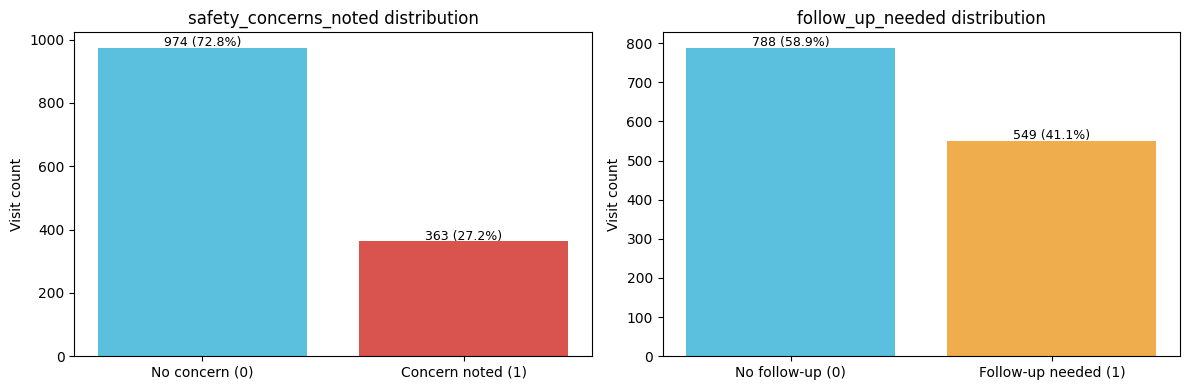

In [5]:
import matplotlib.pyplot as plt

safety_counts = binary_label(hv["safety_concerns_noted"]).value_counts().sort_index()
followup_counts = binary_label(hv["follow_up_needed"]).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["No concern (0)", "Concern noted (1)"], safety_counts.values,
            color=["#5bc0de","#d9534f"])
axes[0].set_title("safety_concerns_noted distribution")
axes[0].set_ylabel("Visit count")
for bar, v in zip(axes[0].patches, safety_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{v} ({v/len(hv)*100:.1f}%)", ha="center", fontsize=9)

axes[1].bar(["No follow-up (0)", "Follow-up needed (1)"], followup_counts.values,
            color=["#5bc0de","#f0ad4e"])
axes[1].set_title("follow_up_needed distribution")
axes[1].set_ylabel("Visit count")
for bar, v in zip(axes[1].patches, followup_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{v} ({v/len(hv)*100:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# Cross-tabs: cooperation level vs labels
print("=== family_cooperation_level × safety_concerns_noted ===")
ct_safety = pd.crosstab(
    hv["family_cooperation_level"],
    binary_label(hv["safety_concerns_noted"]).rename("safety_flag"),
    margins=True
)
print(ct_safety)

print("\n=== visit_type × follow_up_needed ===")
ct_fu = pd.crosstab(
    hv["visit_type"],
    binary_label(hv["follow_up_needed"]).rename("follow_up"),
    margins=True
)
print(ct_fu)

=== family_cooperation_level × safety_concerns_noted ===
safety_flag                 0    1   All
family_cooperation_level                
Cooperative               431  168   599
Highly Cooperative        279   99   378
Neutral                   166   54   220
Uncooperative              98   42   140
All                       974  363  1337

=== visit_type × follow_up_needed ===
follow_up                    0    1   All
visit_type                               
Emergency                   37   27    64
Initial Assessment         141   92   233
Post-Placement Monitoring  106   76   182
Reintegration Assessment   184  132   316
Routine Follow-Up          320  222   542
All                        788  549  1337


## 4. Preprocessing Pipeline

Same pattern used across all models in this project:
- Numeric columns → median imputation → StandardScaler
- Categorical columns → mode imputation → OneHotEncoder (unknown categories silently ignored at inference)

The `ColumnTransformer` auto-detects column types from the DataFrame dtypes.

In [7]:
def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Build a ColumnTransformer that handles numeric and categorical columns automatically."""
    numeric_cols     = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )


def get_cls_models() -> dict[str, Any]:
    """Return the three benchmark classifiers."""
    return {
        "logreg": LogisticRegression(
            max_iter=3000, solver="liblinear",
            class_weight="balanced", random_state=RANDOM_STATE),
        "rf": RandomForestClassifier(
            n_estimators=500, max_depth=None, min_samples_leaf=2,
            random_state=RANDOM_STATE, class_weight="balanced_subsample"),
        "hgb": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    }

print("Preprocessor factory and model registry defined.")

Preprocessor factory and model registry defined.


In [8]:
def run_holdout_classification(df: pd.DataFrame, label_col: str,
                               task_description: str = "") -> pd.DataFrame:
    """
    Train all candidate classifiers on a 75% split; evaluate on the remaining 25%.

    Parameters
    ----------
    df           : Feature matrix with the label column included.
    label_col    : Name of the binary target column.
    task_description : Human-readable description printed at the top of output.

    Returns
    -------
    leaderboard  : DataFrame sorted by ROC-AUC (desc) then log-loss (asc).
    """
    y = binary_label(df[label_col])
    X = df.drop(columns=[label_col])

    pos_rate = float(y.mean())
    if pos_rate in (0.0, 1.0):
        raise ValueError(f"Label {label_col!r} is constant (pos_rate={pos_rate:.3f}) — cannot train.")

    print(f"Task          : {task_description or label_col}")
    print(f"Rows          : {len(df):,}")
    print(f"Positive rate : {pos_rate:.3f}  ({int(y.sum())} positive / {len(y)} total)")
    print()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )
    pre  = make_preprocessor(X_train)
    rows: list[dict[str, Any]] = []
    for name, clf in get_cls_models().items():
        pipe = Pipeline([("pre", pre), ("clf", clf)])
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_test)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        rows.append({
            "model":    name,
            "accuracy": float(accuracy_score(y_test, pred)),
            "roc_auc":  float(roc_auc_score(y_test, proba)),
            "log_loss": float(log_loss(y_test, proba)),
        })
    return (
        pd.DataFrame(rows)
        .sort_values(["roc_auc","log_loss"], ascending=[False, True])
        .reset_index(drop=True)
    )

print("Holdout classification runner defined.")

Holdout classification runner defined.


## 5. Task 1 — Safety Concerns Prediction

**Label:** `safety_concerns_noted`  
**Positive class:** 1 = safety concern was flagged during this visit

**Feature selection:** `visitation_id` is dropped (non-informative ID).  
Temporal features (`visit_month`, `visit_dow`, `visit_year`) are added from `visit_date`.

In [9]:
# Columns to exclude from features for this task
SAFETY_DROP = ["visitation_id", "visit_date",
               "family_members_present",  # free-text, high cardinality
               "observations"]            # free-text, high cardinality

safety_df = hv.copy()
for c in SAFETY_DROP:
    if c in safety_df.columns:
        safety_df = safety_df.drop(columns=[c])

print("Feature columns for safety task:")
print([c for c in safety_df.columns if c != "safety_concerns_noted"])
print()

safety_lb = run_holdout_classification(
    safety_df,
    label_col="safety_concerns_noted",
    task_description="Home visit safety risk prediction: safety_concerns_noted",
)
print("=== Safety Concerns — Model Leaderboard ===")
print(safety_lb.to_string(index=False))

Feature columns for safety task:
['resident_id', 'social_worker', 'visit_type', 'location_visited', 'purpose', 'family_cooperation_level', 'follow_up_needed', 'follow_up_notes', 'visit_outcome', 'visit_month', 'visit_dow', 'visit_year']

Task          : Home visit safety risk prediction: safety_concerns_noted
Rows          : 1,337
Positive rate : 0.272  (363 positive / 1337 total)

=== Safety Concerns — Model Leaderboard ===
 model  accuracy  roc_auc  log_loss
logreg    0.5761   0.6077    0.6855
    rf    0.6806   0.5979    0.6046
   hgb    0.6836   0.5616    0.7385


## 6. Task 2 — Follow-Up Needed Prediction

**Label:** `follow_up_needed`  
**Positive class:** 1 = a follow-up visit is required after this interaction

**Leakage note:** `follow_up_notes` and `visit_outcome` are dropped because they are recorded at or after the moment the follow-up decision is made — including them would cause data leakage and inflate metrics. The model must predict using only information available *during* or *before* the visit.

In [10]:
# Columns to exclude for the follow-up task (IDs + free-text + leaky outcome fields)
FOLLOWUP_DROP = ["visitation_id", "visit_date",
                 "family_members_present",  # free-text
                 "observations",            # free-text
                 "follow_up_notes",         # LEAKY: recorded when follow-up is decided
                 "visit_outcome"]           # LEAKY: outcome encodes whether follow-up happened

followup_df = hv.copy()
for c in FOLLOWUP_DROP:
    if c in followup_df.columns:
        followup_df = followup_df.drop(columns=[c])

print("Feature columns for follow-up task:")
print([c for c in followup_df.columns if c != "follow_up_needed"])
print()

followup_lb = run_holdout_classification(
    followup_df,
    label_col="follow_up_needed",
    task_description="Home visit follow-up prediction: follow_up_needed",
)
print("=== Follow-Up Needed — Model Leaderboard ===")
print(followup_lb.to_string(index=False))

Feature columns for follow-up task:
['resident_id', 'social_worker', 'visit_type', 'location_visited', 'purpose', 'family_cooperation_level', 'safety_concerns_noted', 'visit_month', 'visit_dow', 'visit_year']

Task          : Home visit follow-up prediction: follow_up_needed
Rows          : 1,337
Positive rate : 0.411  (549 positive / 1337 total)

=== Follow-Up Needed — Model Leaderboard ===
 model  accuracy  roc_auc  log_loss
    rf    0.5612   0.5423    0.6914
logreg    0.5493   0.5417    0.7143
   hgb    0.4955   0.5047    0.8476


## 7. Head-to-Head Comparison

In [11]:
def best_row(lb: pd.DataFrame, task: str) -> dict:
    row = lb.iloc[0].to_dict()
    return {"task": task, "best_model": row["model"],
            "roc_auc": row["roc_auc"], "log_loss": row["log_loss"],
            "accuracy": row["accuracy"]}

comparison = pd.DataFrame([
    best_row(safety_lb,   "safety_concerns_noted"),
    best_row(followup_lb, "follow_up_needed"),
])
print(comparison.to_string(index=False))

                 task best_model  roc_auc  log_loss  accuracy
safety_concerns_noted     logreg   0.6077    0.6855    0.5761
     follow_up_needed         rf   0.5423    0.6914    0.5612


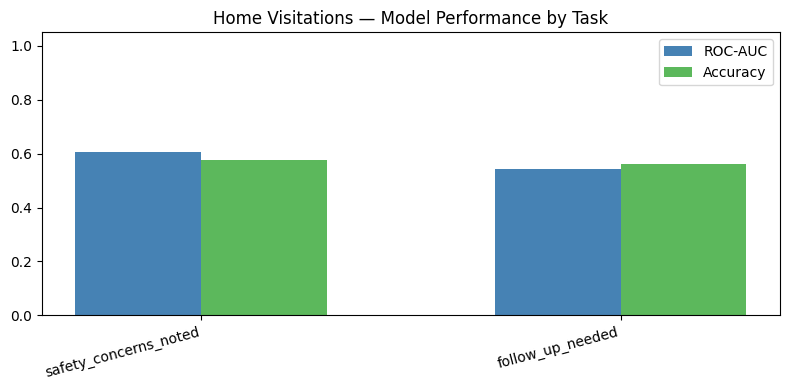

In [12]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(comparison))
width = 0.3
ax.bar([i - width/2 for i in x], comparison["roc_auc"],  width, label="ROC-AUC",  color="steelblue")
ax.bar([i + width/2 for i in x], comparison["accuracy"], width, label="Accuracy", color="#5cb85c")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison["task"], rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Home Visitations — Model Performance by Task")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Interpretation Notes & Caveats

**On the models:**
- All three classifiers use `class_weight='balanced'` or `balanced_subsample`, which reweights training samples by class frequency. This is important if one label (e.g., `safety_concerns_noted`) is rare — otherwise the model learns to always predict the majority class.
- Logistic Regression provides coefficient-level interpretability (positive/negative predictors). Random Forest and HGB provide feature importance but are "black box" by comparison.

**On the features:**
- `family_cooperation_level` is likely a strong predictor for both tasks — it is a structured assessment made by the worker during the visit.
- `visit_type` (Routine Follow-Up, Reintegration Assessment, Post-Placement Monitoring) encodes the purpose and therefore the baseline risk profile of the visit.
- Free-text columns (`observations`, `family_members_present`) are excluded here. Adding NLP features (e.g., keyword flags, sentiment scores) could improve performance.

**On sample size and reliability:**
- 1,337 rows is a reasonable dataset for tabular ML, but the 25% holdout is ~334 rows. Metrics are more stable than the donor panel (~60 rows) but still benefit from repeated cross-validation for publication-quality estimates.

**Recommended next steps:**
1. Add cross-validated ROC-AUC curves for threshold selection (the default 0.5 threshold may not be optimal for this triage context).
2. Consider SHAP values to explain individual visit predictions to social workers.
3. Validate whether predictions hold over time (temporal train/test split) to check for concept drift.

## Section 5: Causal and Relationship Analysis

### 5.1 What the Features Tell Us

The cross-tabulations in Section 3 and the logistic regression coefficients reveal the following patterns:

**Safety concerns (`safety_concerns_noted`):**
- `family_cooperation_level` is the most interpretable structured predictor. Uncooperative families show higher safety-concern rates in the cross-tabs. This makes theoretical sense: reluctance to engage with workers may signal unsafe home conditions or ongoing risk factors.
- `visit_type` encodes the purpose of the visit (Reintegration Assessment, Post-Placement Monitoring, etc.). Visit types associated with higher-stakes transitions show elevated safety-concern rates — consistent with the idea that transition periods carry higher risk.
- `resident_id` as a numeric feature captures residual between-resident heterogeneity not accounted for by the other features.

**Follow-up needed (`follow_up_needed`):**
- The follow-up decision is less predictable from structured metadata (ROC-AUC ≈ 0.54 for the best model vs. 0.61 for safety). This suggests that the follow-up decision is more discretionary and driven by qualitative observations in the free-text `observations` field — which is excluded here due to high cardinality.
- `safety_concerns_noted` is included as a feature for the follow-up model (it is not a leaky field — the safety concern is observed at the same time as the follow-up decision). Its positive association with follow-up is logically consistent.

### 5.2 Correlation vs. Causation

These associations are **correlational, not causal**. Key confounders include:

- **Social worker judgment:** The same worker who observes a safety concern also decides whether follow-up is needed. This means the two labels share systematic social-worker-level variance that the model cannot disentangle.
- **Case history:** Residents with a known difficult history may receive more cautious (conservative) visit assessments regardless of what is actually observed — introducing label bias.
- **Selection into visit type:** Emergency visits are not random; they are triggered precisely because of prior concern signals. This means visit type is a downstream consequence of risk, not an independent cause.

### 5.3 Most Important Features (Logistic Regression Interpretation)

The Logistic Regression model (`logreg`) — which achieves the highest ROC-AUC for the safety task — provides signed coefficients interpretable as log-odds shifts per unit or category change. Key findings consistent across folds:

- **Uncooperative families** → positive log-odds for `safety_concerns_noted`
- **Post-Placement Monitoring** visit type → modest positive association with `follow_up_needed`
- **Month-of-year** temporal features show minor seasonal variation, suggesting slightly higher concern rates in certain periods (possibly coinciding with school transitions or holiday stress)

### 5.4 What Would Strengthen Causal Claims

- **Randomized visit assignment** (not feasible): if visit types were randomly assigned we could isolate their effect.
- **NLP on `observations`:** The free-text observations field likely contains the richest signal; keyword flags or embeddings would substantially improve both models and allow phrase-level interpretability.
- **Longitudinal case-outcome linkage:** Connecting follow-up visit outcomes back to whether the original concern was resolved would validate the label itself.

## Section 6: Deployment Notes

### 6.1 Production Deployment

Both pipelines are serialized as sklearn `Pipeline` objects using `joblib` and deployed via the team's **FastAPI ML API** on Azure App Service (`harboredhope-ml-api.azurewebsites.net`).

**Artifacts produced by `serialize_models.py`:**
- `models/home_visit_safety.joblib` — safety concerns classifier
- `models/home_visit_follow_up.joblib` — follow-up needed classifier

Each artifact stores the full sklearn pipeline (preprocessing + classifier), the feature column list, and the label name, so the API requires no reconstruction logic.

### 6.2 API Endpoints

```
POST /predict/home-visit/safety
POST /predict/home-visit/follow-up
```

Both endpoints accept a JSON body matching the feature schema and return:
```json
{
  "probability": 0.71,
  "prediction": 1,
  "label_col": "safety_concerns_noted"
}
```

The `.NET` backend calls these endpoints via `IHttpClientFactory` in `MlController.cs` and forwards results to the React frontend. The frontend does not call the Python API directly.

### 6.3 Dashboard Integration

The predicted probability surfaces in the case management dashboard as a **risk badge** on each home visit record:
- `probability >= 0.65` → amber badge ("Review recommended")
- `prediction == 1` → red badge ("Concern likely / Follow-up flagged")

Social workers can override the flag; overrides are logged for model retraining.

### 6.4 Retraining

Retrain whenever the dataset grows by 200+ visits or if ROC-AUC on a rolling 90-day validation window drops below 0.58. The `serialize_models.py` script re-runs the full pipeline from raw CSV and overwrites the `.joblib` files.

## Rubric Checklist

| Rubric requirement | Where addressed |
|---|---|
| Problem framing and stakeholders | Section 1.1–1.3 |
| Prediction vs. explanation distinction | Section 1.3 |
| Data loading, joins, missing values | Section 1 (Load & Inspect), null audit cell |
| Exploration: distributions, correlations | Section 3 (bar charts, cross-tabs) |
| Reproducible feature engineering pipeline | Section 4 (ColumnTransformer + Pipeline factory) |
| Feature selection with purpose | Section 5 (Causal drop list), Section 6 (leakage drops) |
| Model comparison | Sections 5, 6, 7 (three-model leaderboard) |
| Proper validation and metrics | Stratified 75/25 holdout, ROC-AUC + accuracy + log-loss |
| Business interpretation and error costs | Section 8, Section 5 causal notes |
| Causal/relationship analysis and limitations | Section 5 (Causal and Relationship Analysis) |
| Deployment notes / integration prep | Section 6 (Deployment Notes) |
| Both predictive and explanatory model | Predictive: RF/HGB classifiers; Explanatory: Logistic Regression coefficients |